# M0 · Data pipeline and parameter check

**Project:** GBLA, Generator-Balanced Latent Adaptation for generalizable, parameter-efficient deepfake detection.

**Goal of M0:** turn the FaceForensics++ c23 data already on C-DAC (videos + 32 extracted frames per video) into paired face crops with an index, and verify the parameter counts the method relies on.

| Section | What it does | Run time |
|---|---|---|
| 1. Setup | paths, packages, environment | minutes |
| 2. Data on C-DAC | locate and inspect the data, official splits | minutes |
| 3. Face extraction | helpers, smoke test, full run (resume-safe) | hours |
| 4. Extraction check | progress and failures | about a minute |
| 5. Index | one row per crop, with real–fake pairing | minutes |
| 6. Parameter report | CLIP LayerNorm / head counts, GBLA budget | minutes |
| 7. Send results back | push this notebook with its outputs | – |

The input folders are only read, never modified. Everything we create (face crops, boxes, index CSV) goes under `DATA_ROOT`, outside the git repository. Only this notebook goes into git.

## 1. Setup

### 1.1 Paths and settings

Every later cell reads from these variables.

- `RAW_ROOT`: the Kaggle FF++ c23 videos. `FRAMES_ROOT`: the 32 frames per video already extracted from them. Both are only read.
- `DATA_ROOT`: our outputs. It is on persistent storage (your home on `/nlsasfs`), which matters because extraction resumes from what is already on disk. Keep the same `DATA_ROOT` and settings between runs.
- `FRAME_SOURCE = "frames"` uses the pre-extracted frames (fast). `"videos"` decodes the videos instead (fallback, only if section 2.2 shows the frames are unsuitable; don't switch in the middle of an extraction).

In [1]:
# 1.1 Paths and settings
from pathlib import Path

# inputs (already on C-DAC; read only)
RAW_ROOT = Path("/nlsasfs/home/isea/isea64/ffc23dataset/kaggledata/FaceForensics++_C23")
FRAMES_ROOT = Path("/nlsasfs/home/isea/isea64/ffc23dataset/frames_all")

# outputs (ours)
DATA_ROOT = Path("/nlsasfs/home/isea/isea64/GBLA-Deepfake Detection")
SPLITS_DIR = DATA_ROOT / "splits"
FACES_ROOT = DATA_ROOT / "faces"
INDEX_CSV = DATA_ROOT / "index" / "ffpp_c23.csv"

MANIPULATIONS = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures", "FaceShifter"]
CATEGORIES = ["original"] + MANIPULATIONS
# accepted folder names per category, matched case-insensitively
# (DeepFakeDetection is not one of the 5 training manipulations; it is kept aside for cross-dataset tests later)
FOLDER_ALIASES = {
    "original": ["original", "original_sequences", "youtube"],
    "Deepfakes": ["Deepfakes"],
    "Face2Face": ["Face2Face"],
    "FaceSwap": ["FaceSwap"],
    "NeuralTextures": ["NeuralTextures", "NaturalTextures"],
    "FaceShifter": ["FaceShifter"],
}

FRAME_SOURCE = "frames"  # "frames" = images in FRAMES_ROOT; "videos" = decode videos in RAW_ROOT
FRAMES_PER_VIDEO = 32    # used when FRAME_SOURCE = "videos"
CROP_SCALE = 1.3         # square box side = scale x max(face width, face height)
IMAGE_SIZE = 224
IMAGE_FORMAT = "png"     # lossless, so no extra compression artifacts are added
MIN_FACE_PROB = 0.9
DETECTOR_BATCH = 16
LOAD_WORKERS = 4         # threads loading original frames while the GPU detects faces
CROP_WORKERS = 12        # threads cropping manipulated videos (CPU only)
RETRY_FAILED = False     # True = retry videos marked as failed (no face / unreadable) in an earlier run
SEED = 0

for d in (DATA_ROOT, SPLITS_DIR, FACES_ROOT, INDEX_CSV.parent):
    d.mkdir(parents=True, exist_ok=True)
print("outputs go to:", DATA_ROOT)

outputs go to: /nlsasfs/home/isea/isea64/GBLA-Deepfake Detection


### 1.2 Install packages

Uses the PyTorch already installed on C-DAC. `facenet-pytorch` (the MTCNN face detector) is installed with `--no-deps` so it cannot replace that PyTorch. If anything was newly installed, restart the kernel once (Kernel → Restart) and rerun 1.1. Only needed the first time.

In [2]:
# 1.2 Install packages
%pip install -q open_clip_torch opencv-python-headless pandas tqdm requests matplotlib
%pip install -q --no-deps facenet-pytorch

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### 1.3 Imports and environment

The table printed here is part of the results I need: software versions and the GPU.

In [3]:
# 1.3 Imports and environment
import json, os, platform, random, re, sys, time
from collections import Counter, deque
from concurrent.futures import ThreadPoolExecutor
from itertools import islice

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from PIL import Image
from tqdm.auto import tqdm

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

env = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "torch": torch.__version__,
    "torch CUDA": torch.version.cuda,
    "device": DEVICE,
    "GPU": torch.cuda.get_device_name(0) if DEVICE == "cuda" else None,
    "GPU memory (GB)": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if DEVICE == "cuda" else None,
    "opencv": cv2.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
pd.Series(env, name="value").to_frame()

/nlsasfs/home/isea/isea64/venv_jupyter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,value
python,3.10.12
platform,Linux-5.15.0-1062-nvidia-x86_64-with-glibc2.35
torch,2.6.0+cu124
torch CUDA,12.4
device,cuda
GPU,NVIDIA A100-SXM4-40GB
GPU memory (GB),42.3
opencv,5.0.0
numpy,2.2.6
pandas,2.3.3


## 2. Data on C-DAC

The data is already on C-DAC, so nothing is downloaded except the official split lists:

- `RAW_ROOT` holds the Kaggle FF++ c23 videos: `csv`, `DeepFakeDetection`, `DeepFakes`, `Face2Face`, `FaceShifter`, `FaceSwap`, `NeuralTextures`, `original`.
- `FRAMES_ROOT` holds 32 frames per video, already extracted.

We use `original` + the 5 manipulations. Folder names are matched case-insensitively with aliases (see `FOLDER_ALIASES` in 1.1), so `DeepFakes`/`Deepfakes` and `NaturalTextures`/`NeuralTextures` both work.

### 2.1 Locate the data

Finds each category in both folders and counts videos and frame folders. A frame folder is any folder, at any depth, that directly contains images; its name is the video id (`000`, `000_003`, ...). Scanning can take a minute or two on the shared file system.

Expected per category: 1000 videos, 1000 frame folders, 32 frames per folder, and 0 in the last two columns (ids that appear only in one of the two places).

In [4]:
import os
os.listdir("/nlsasfs/home/isea/isea64/ffc23dataset/frames_all")

['NeuralTextures',
 'DeepFakeDetection',
 'Face2Face',
 'FaceSwap',
 'original',
 'split',
 'FaceShifter',
 'Deepfakes']

In [5]:
# 2.1 Locate the data
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}


def natural_key(p):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", p.name)]


def find_dir(root, category):
    """Category folder directly under root (case-insensitive, aliases allowed), or None."""
    if not root.is_dir():
        return None
    wanted = {a.lower() for a in FOLDER_ALIASES[category]}
    matches = [d for d in sorted(root.iterdir()) if d.is_dir() and d.name.lower() in wanted]
    return matches[0] if matches else None


def clean_id(name):
    return name[:-4] if name.lower().endswith(".mp4") else name


def find_videos(folder):
    return {p.stem: p for p in sorted(folder.rglob("*.mp4"))} if folder else {}


def find_frame_folders(folder):
    """
    Flat-frame dataset:
        000_frame_00.jpg
        000_frame_01.jpg
        ...
        000_003_frame_00.jpg

    Returns:
        {video_id: category_folder}
    """
    found = {}

    if folder is None or not folder.is_dir():
        return found

    for p in folder.iterdir():
        if not p.is_file() or p.suffix.lower() not in IMAGE_EXTS:
            continue

        m = re.match(r"^(.+)_frame_(\d+)$", p.stem)
        if not m:
            continue

        video_id = m.group(1)

        if video_id not in found:
            found[video_id] = folder

    return found


def frame_files(folder, video_id=None):
    """
    Return {frame_number: image_path} for one video
    from the flat frame directory.
    """
    if folder is None or not folder.is_dir():
        return {}

    files = {}

    for p in folder.iterdir():
        if not p.is_file() or p.suffix.lower() not in IMAGE_EXTS:
            continue

        m = re.match(r"^(.+)_frame_(\d+)$", p.stem)
        if not m:
            continue

        vid = m.group(1)
        frame_idx = int(m.group(2))

        if video_id is not None and vid != video_id:
            continue

        files[frame_idx] = p

    return dict(sorted(files.items()))


def video_ids(category):
    """Video ids of a category in the active FRAME_SOURCE."""
    return sorted(SOURCES[category]["frames" if FRAME_SOURCE == "frames" else "videos"])


assert FRAME_SOURCE in ("frames", "videos")
assert RAW_ROOT.is_dir(), f"not found: {RAW_ROOT}"
if FRAME_SOURCE == "frames":
    assert FRAMES_ROOT.is_dir(), f"not found: {FRAMES_ROOT}"
print("RAW_ROOT   :", sorted(p.name for p in RAW_ROOT.iterdir()))
print("FRAMES_ROOT:", sorted(p.name for p in FRAMES_ROOT.iterdir()) if FRAMES_ROOT.is_dir() else "missing")
if (RAW_ROOT / "csv").is_dir():
    print("csv folder :", sorted(p.name for p in (RAW_ROOT / "csv").iterdir()))

SOURCES, rows = {}, []

for cat in tqdm(CATEGORIES, desc="scanning"):
    raw_dir = find_dir(RAW_ROOT, cat)
    frames_dir = find_dir(FRAMES_ROOT, cat)

    videos = find_videos(raw_dir)
    frames = find_frame_folders(frames_dir)

    SOURCES[cat] = {
        "videos": videos,
        "frames": frames
    }

    # Count frames once per video instead of rescanning the directory
    frame_counts = {}

    if frames_dir is not None:
        for p in frames_dir.iterdir():
            if not p.is_file() or p.suffix.lower() not in IMAGE_EXTS:
                continue

            m = re.match(r"^(.+)_frame_(\d+)$", p.stem)
            if not m:
                continue

            vid = m.group(1)
            frame_counts[vid] = frame_counts.get(vid, 0) + 1

    n_frames = pd.Series(
        list(frame_counts.values()),
        dtype=float
    )

    rows.append({
        "category": cat,
        "raw folder": raw_dir.name if raw_dir else "MISSING",
        "videos": len(videos),
        "frames folder": frames_dir.name if frames_dir else "MISSING",
        "frame folders": len(frames),
        "frames/video min": n_frames.min() if not n_frames.empty else None,
        "median": n_frames.median() if not n_frames.empty else None,
        "max": n_frames.max() if not n_frames.empty else None,
        "ids only in frames": len(set(frames) - set(videos)),
        "ids only in videos": len(set(videos) - set(frames)),
    })

display(pd.DataFrame(rows))

RAW_ROOT   : ['DeepFakeDetection', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures', 'csv', 'original']
FRAMES_ROOT: ['DeepFakeDetection', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures', 'original', 'split']
csv folder : ['DeepFakeDetection.csv', 'Deepfakes.csv', 'FF++_Metadata.csv', 'FF++_Metadata_Shuffled.csv', 'Face2Face.csv', 'FaceShifter.csv', 'FaceSwap.csv', 'Mean_Data.csv', 'NeuralTextures.csv', 'original.csv']


scanning: 100%|██████████| 6/6 [01:39<00:00, 16.60s/it]


,category,raw folder,videos,frames folder,frame folders,frames/video min,median,max,ids only in frames,ids only in videos
0,original,original,1000,original,1000,32.0,32.0,32.0,0,0
1,Deepfakes,Deepfakes,1000,Deepfakes,1000,32.0,32.0,32.0,0,0
2,Face2Face,Face2Face,1000,Face2Face,1000,32.0,32.0,32.0,0,0
3,FaceSwap,FaceSwap,1000,FaceSwap,1000,32.0,32.0,32.0,0,0
4,NeuralTextures,NeuralTextures,1000,NeuralTextures,1000,32.0,32.0,32.0,0,0
5,FaceShifter,FaceShifter,1000,FaceShifter,1000,32.0,32.0,32.0,0,0


In [6]:
for cat in CATEGORIES:
    vids = video_ids(cat)
    print(cat, "count =", len(vids), "first =", vids[:5])

original count = 1000 first = ['000', '001', '002', '003', '004']
Deepfakes count = 1000 first = ['000_003', '001_870', '002_006', '003_000', '004_982']
Face2Face count = 1000 first = ['000_003', '001_870', '002_006', '003_000', '004_982']
FaceSwap count = 1000 first = ['000_003', '001_870', '002_006', '003_000', '004_982']
NeuralTextures count = 1000 first = ['000_003', '001_870', '002_006', '003_000', '004_982']
FaceShifter count = 1000 first = ['000_003', '001_870', '002_006', '003_000', '004_982']


### 2.2 Inspect one example

For the first original video and its fake in each manipulation, this shows the frame folder, the first file names, the frame keys, the image size against the video resolution, and the first frame of each. Check two columns:

- **`full frames` = True**: the images are whole video frames, so we detect and crop the faces ourselves (expected).
- **`same keys as original` = True**: the fakes were sampled at the same frames as the original, so every fake crop gets an exactly matching real crop.

If either is False, **stop here** and push the notebook (section 7) so I can adapt section 3. Setting `FRAME_SOURCE = "videos"` in 1.1 is the fallback that always works, but it is slower.

,category,video,video resolution,frames folder,n frames,first files,keys,image size,full frames,same keys as original
0,original,000,"(640, 480)",original,32,"743_frame_00.jpg, 750_frame_01.jpg, 363_frame_...","[0, 1, 2, 3] ... 31","(1280, 720)",False,True
1,Deepfakes,000_003,"(640, 480)",Deepfakes,32,"787_782_frame_00.jpg, 539_499_frame_01.jpg, 07...","[0, 1, 2, 3] ... 31","(656, 480)",False,True
2,Face2Face,000_003,"(640, 480)",Face2Face,32,"824_419_frame_00.jpg, 295_099_frame_01.jpg, 07...","[0, 1, 2, 3] ... 31","(1280, 720)",False,True
3,FaceSwap,000_003,"(640, 480)",FaceSwap,32,"787_782_frame_00.jpg, 539_499_frame_01.jpg, 07...","[0, 1, 2, 3] ... 31","(656, 480)",False,True
4,NeuralTextures,000_003,"(640, 480)",NeuralTextures,32,"824_419_frame_00.jpg, 295_099_frame_01.jpg, 07...","[0, 1, 2, 3] ... 31","(1280, 720)",False,True
5,FaceShifter,000_003,"(640, 480)",FaceShifter,32,"787_782_frame_00.jpg, 539_499_frame_01.jpg, 07...","[0, 1, 2, 3] ... 31","(656, 480)",False,True


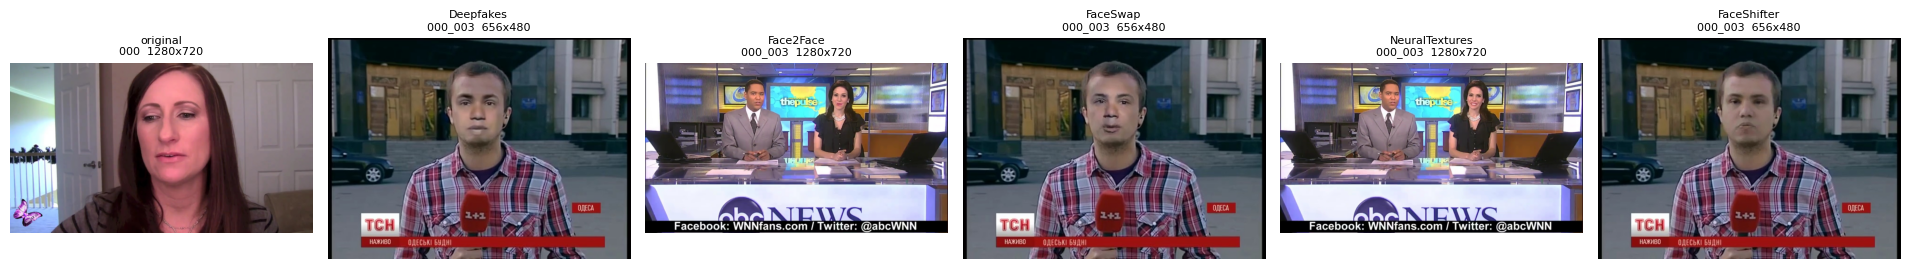

In [7]:
# 2.2 Inspect one example
def video_size(path):
    cap = cv2.VideoCapture(str(path))
    size = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    cap.release()
    return size


example = video_ids("original")[0]
members = [("original", example)] + [
    (m, next((v for v in video_ids(m) if v.split("_")[0] == example), None)) for m in MANIPULATIONS]

rows, images, orig_keys = [], [], None
for cat, vid in members:
    if vid is None:
        rows.append({"category": cat, "video": "no fake of this target found"})
        continue
    video = SOURCES[cat]["videos"].get(vid)
    row = {"category": cat, "video": vid, "video resolution": video_size(video) if video else None}
    folder = SOURCES[cat]["frames"].get(vid)
    if folder:
        files = frame_files(folder)
        keys = sorted(files)
        if cat == "original":
            orig_keys = keys
        first = Image.open(files[keys[0]])
        row.update({
            "frames folder": str(folder.relative_to(FRAMES_ROOT)),
            "n frames": len(keys),
            "first files": ", ".join(p.name for p in list(files.values())[:3]),
            "keys": f"{keys[:4]} ... {keys[-1]}",
            "image size": first.size,
            "full frames": first.size == row["video resolution"],
            "same keys as original": keys == orig_keys,
        })
        images.append((f"{cat}\n{vid}  {first.size[0]}x{first.size[1]}", first))
    rows.append(row)
display(pd.DataFrame(rows))

if images:
    fig, axes = plt.subplots(1, len(images), figsize=(3.2 * len(images), 2.8), squeeze=False)
    for ax, (title, img) in zip(axes[0], images):
        ax.imshow(img)
        ax.set_title(title, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### 2.3 Official splits

The Kaggle copy has no train/val/test split, so we use the official FF++ lists (needs internet). They are lists of video pairs `[a, b]`; a split contains originals `a` and `b` and fakes `a_b` and `b_a`. Expected: 360 / 70 / 70 pairs, i.e. 720 / 140 / 140 original videos.

In [8]:
# 2.3 Official train / val / test splits
SPLITS_URL = "https://raw.githubusercontent.com/ondyari/FaceForensics/master/dataset/splits/{}.json"
EXPECTED_PAIRS = {"train": 360, "val": 70, "test": 70}

for split, expected in EXPECTED_PAIRS.items():
    path = SPLITS_DIR / f"{split}.json"
    if not path.exists():
        resp = requests.get(SPLITS_URL.format(split), timeout=30)
        resp.raise_for_status()
        path.write_text(resp.text)
    pairs = json.loads(path.read_text())
    assert len(pairs) == expected, f"{split}: expected {expected} pairs, got {len(pairs)}"
    print(f"{split}: {len(pairs)} pairs -> {2 * len(pairs)} original videos")

train: 360 pairs -> 720 original videos
val: 70 pairs -> 140 original videos
test: 70 pairs -> 140 original videos


## 3. Face extraction

How the crops are made:

- The source is the 32 frames per video in `FRAMES_ROOT` (or 32 evenly spaced frames decoded from the video if `FRAME_SOURCE = "videos"`). Each frame has a **key**: the number in its file name (the frame index).
- Faces are detected with MTCNN on the **original** frames only, cut as a 1.3× square box, resized to 224×224 and saved as PNG to `FACES_ROOT/<category>/<video id>/<key>.png`.
- A fake `<target>_<source>` keeps the target's geometry, so it is cropped with the **target's box for the same frame key**. The fake crop and its real crop then cover exactly the same region, and crop position cannot become a real/fake cue. If a fake has a frame key the original doesn't have, the box of the nearest original frame is used (counted in the output).

**Resume safety.** Extraction can be stopped at any moment (kernel crash, session timeout, closing everything) and rerun days later; nothing finished is redone:

| situation on disk | what a rerun does |
|---|---|
| video has `_done` | skipped without reading any frame |
| video has `_failed` (no face / unreadable) | skipped, unless `RETRY_FAILED = True` |
| original with saved boxes but some crops missing (interrupted part-way) | no face detection again; writes only the missing crops |
| fake with some crops missing | writes only the missing crops |
| unexpected error (disk full, corrupt file, GPU error, ...) | logged, that video is left for the next run, the rest continue |

- Every image and box file is written to a temporary file and then renamed, so an interruption can never leave a half-written crop that looks finished.
- Boxes are saved before the crops, so detection is never repeated for a video once it has run.
- Everything is logged with a timestamp to `FACES_ROOT/extraction_log.tsv`; section 4 shows the current state.

### 3.1 Helper functions

In [9]:
# 3.1 Helper functions

# ---------- reading frames (from FRAMES_ROOT images, or decoded from videos) ----------
def frame_count(path):
    cap = cv2.VideoCapture(str(path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return n


def sample_indices(n_frames, k=FRAMES_PER_VIDEO):
    if n_frames <= 0:
        return []
    return sorted(set(np.linspace(0, n_frames - 1, min(k, n_frames)).round().astype(int).tolist()))


def read_frames(path, indices):
    """Decode sequentially (seeking is unreliable for some codecs) and keep the wanted frames."""
    wanted, last, frames = set(indices), max(indices, default=-1), {}
    cap = cv2.VideoCapture(str(path))
    i = 0
    while i <= last and cap.grab():
        if i in wanted:
            ok, frame = cap.retrieve()
            if ok:
                frames[i] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        i += 1
    cap.release()
    return frames


def source_keys(category, vid):
    """Sorted frame keys available for one video."""
    if FRAME_SOURCE == "frames":
        folder = SOURCES[category]["frames"].get(vid)

        if folder is None:
            return []

        return sorted(frame_files(folder, vid))

    path = SOURCES[category]["videos"].get(vid)

    return sample_indices(frame_count(path)) if path else []


def load_frames(category, vid, keys):
    """{key: RGB frame} for the requested keys."""
    if not keys:
        return {}

    if FRAME_SOURCE == "videos":
        return read_frames(
            SOURCES[category]["videos"][vid],
            keys
        )

    folder = SOURCES[category]["frames"][vid]
    files = frame_files(folder, vid)

    frames = {}

    for k in keys:
        img = cv2.imread(str(files[k])) if k in files else None

        if img is not None:
            frames[k] = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )

    return frames


# ---------- face boxes ----------
def pick_face(boxes, probs):
    """Largest confident face in a frame, or None."""
    if boxes is None:
        return None
    confident = [b for b, p in zip(boxes, probs) if p is not None and p >= MIN_FACE_PROB]
    if not confident:
        return None
    return [float(v) for v in max(confident, key=lambda b: (b[2] - b[0]) * (b[3] - b[1]))]


def fill_missing(raw):
    """Frames without a detection take the box of the nearest frame that has one."""
    found = [i for i, b in raw.items() if b is not None]
    if not found:
        return None
    return {i: b if b is not None else raw[min(found, key=lambda j: abs(j - i))]
            for i, b in raw.items()}


def square_box(box, width, height):
    x0, y0, x1, y1 = box
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    side = min(max(x1 - x0, y1 - y0) * CROP_SCALE, width, height)
    left = int(round(min(max(cx - side / 2, 0), width - side)))
    top = int(round(min(max(cy - side / 2, 0), height - side)))
    s = int(round(side))
    return [left, top, left + s, top + s]


BOX_DIR = FACES_ROOT / "_boxes"
BOX_DIR.mkdir(parents=True, exist_ok=True)


def load_boxes(vid):
    """Saved crop boxes of an original as ((width, height), {key: box}), or None if not detected yet."""
    path = BOX_DIR / f"{vid}.json"
    if not path.exists():
        return None
    meta = json.loads(path.read_text())
    if meta.get("source", FRAME_SOURCE) != FRAME_SOURCE:
        raise RuntimeError(f"boxes of {vid} were made with FRAME_SOURCE={meta['source']!r}")
    return tuple(meta["size"]), {int(k): b for k, b in meta["boxes"].items()}


# ---------- resume-safe writing and state ----------
SAVE_FORMAT = Image.registered_extensions()["." + IMAGE_FORMAT]


def crop_path(out_dir, key):
    return out_dir / f"{key:04d}.{IMAGE_FORMAT}"


def save_crop(frame, box, out_path):
    """Write to a temp file, then rename: an interruption never leaves a half-written image."""
    x0, y0, x1, y1 = box
    tmp = out_path.with_name(out_path.name + ".tmp")
    crop = Image.fromarray(frame[y0:y1, x0:x1]).resize((IMAGE_SIZE, IMAGE_SIZE), Image.BICUBIC)
    crop.save(tmp, format=SAVE_FORMAT)
    os.replace(tmp, out_path)


def write_json(path, obj):
    tmp = path.with_name(path.name + ".tmp")
    tmp.write_text(json.dumps(obj))
    os.replace(tmp, path)


def missing_crops(out_dir, keys):
    return [k for k in sorted(keys) if not crop_path(out_dir, k).exists()]


def video_state(out_dir):
    """'done', 'failed' (skipped unless RETRY_FAILED) or 'todo' (not started or interrupted)."""
    if (out_dir / "_done").exists():
        return "done"
    if (out_dir / "_failed").exists() and not RETRY_FAILED:
        return "failed"
    return "todo"


def mark_done(out_dir, n_missing=0):
    """n_missing = frames that could not be read (reading is deterministic, retrying won't help)."""
    (out_dir / "_failed").unlink(missing_ok=True)
    (out_dir / "_done").write_text(str(n_missing))


def mark_failed(out_dir, reason):
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "_failed").write_text(reason)


def log_event(video_id, message):
    with open(FACES_ROOT / "extraction_log.tsv", "a") as f:
        f.write(f"{time.strftime('%Y-%m-%d %H:%M:%S')}\t{video_id}\t{message}\n")


def bounded_map(fn, items, workers):
    """Threaded map that holds at most 2 x workers results in memory (frames are large)."""
    items = iter(items)
    with ThreadPoolExecutor(workers) as pool:
        pending = deque(pool.submit(fn, x) for x in islice(items, 2 * workers))
        while pending:
            result = pending.popleft().result()
            for x in islice(items, 1):
                pending.append(pool.submit(fn, x))
            yield result

### 3.2 Originals: detect faces and save crops

Frames are loaded in `LOAD_WORKERS` background threads while the GPU detects faces. The boxes of each original are saved to `FACES_ROOT/_boxes/<id>.json` **before** its crops are written; they are reused for an interrupted original and for all its fakes in 3.3.

In [10]:
# 3.2 Originals: detect faces and save crops
from facenet_pytorch import MTCNN

mtcnn = MTCNN(keep_all=True, device=DEVICE, post_process=False)


def load_original(vid):
    """Background thread: load only the frames this video still needs.
    Returns (vid, status, payload, crops); payload = {key: frame}, or the error text."""
    out_dir = FACES_ROOT / "original" / vid
    state = video_state(out_dir)
    if state != "todo":
        return vid, state, None, None
    try:
        boxes = load_boxes(vid)
        if boxes is not None:
            _, crops = boxes
            return vid, "resume", load_frames("original", vid, missing_crops(out_dir, crops)), crops
        return vid, "new", load_frames("original", vid, source_keys("original", vid)), None
    except Exception as e:
        return vid, "error", repr(e), None


def detect_crops(frames):
    """({key: square box}, (width, height)), or None if no confident face in any frame."""
    keys = sorted(frames)
    raw = {}
    for start in range(0, len(keys), DETECTOR_BATCH):
        chunk = keys[start:start + DETECTOR_BATCH]
        boxes, probs = mtcnn.detect([Image.fromarray(frames[k]) for k in chunk])
        for k, b, p in zip(chunk, boxes, probs):
            raw[k] = pick_face(b, p)
    filled = fill_missing(raw)
    if filled is None:
        return None
    h, w = frames[keys[0]].shape[:2]
    return {k: square_box(filled[k], w, h) for k in keys}, (w, h)


def run_originals(vids):
    stats = Counter()
    for vid, status, payload, crops in tqdm(bounded_map(load_original, vids, LOAD_WORKERS),
                                            total=len(vids), desc="original"):
        video_id = f"original/{vid}"
        out_dir = FACES_ROOT / "original" / vid
        if status in ("done", "failed"):
            stats[f"skipped ({status} earlier)"] += 1
            continue
        if status == "error":
            stats["error (retried next run)"] += 1
            log_event(video_id, f"error: {payload}")
            continue
        try:
            frames = payload
            if status == "new":
                if not frames:
                    mark_failed(out_dir, "unreadable")
                    log_event(video_id, "failed: unreadable")
                    stats["failed: unreadable"] += 1
                    continue
                detected = detect_crops(frames)
                if detected is None:
                    mark_failed(out_dir, "no_face")
                    log_event(video_id, "failed: no_face")
                    stats["failed: no_face"] += 1
                    continue
                crops, (w, h) = detected
                write_json(BOX_DIR / f"{vid}.json", {"source": FRAME_SOURCE, "size": [w, h],
                                                     "boxes": {str(k): b for k, b in crops.items()}})

            out_dir.mkdir(parents=True, exist_ok=True)
            for k, frame in frames.items():
                save_crop(frame, crops[k], crop_path(out_dir, k))
            left = missing_crops(out_dir, crops)
            if len(left) == len(crops):
                mark_failed(out_dir, "unreadable")
                log_event(video_id, "failed: unreadable")
                stats["failed: unreadable"] += 1
                continue
            mark_done(out_dir, len(left))
            stats["extracted" if status == "new" else "resumed (only missing crops)"] += 1
        except Exception as e:
            stats["error (retried next run)"] += 1
            log_event(video_id, f"error: {e!r}")
    print(dict(stats))

### 3.3 Manipulations: crop with the original's boxes

CPU only, `CROP_WORKERS` threads. A fake whose original has not been processed yet is reported as `waiting` and picked up automatically on the next run. A fake whose original failed (no face) is marked failed too. `frames with nearest box` counts fake frames whose key had no exact match in the original (ideally 0).

In [11]:
# 3.3 Manipulations: crop with the original's boxes
def crop_manipulated(task):
    """Worker thread: write only the missing crops of one fake video.
    Returns (video_id, status, number of frames that used the nearest original box)."""
    manip, vid = task
    video_id = f"{manip}/{vid}"
    out_dir = FACES_ROOT / manip / vid
    state = video_state(out_dir)
    if state != "todo":
        return video_id, f"skipped ({state} earlier)", 0
    try:
        target = vid.split("_")[0]
        boxes = load_boxes(target)
        if boxes is None:
            target_failed = FACES_ROOT / "original" / target / "_failed"
            if target_failed.exists():
                mark_failed(out_dir, f"original_failed:{target_failed.read_text()}")
                return video_id, "failed: original failed", 0
            return video_id, "waiting (original not extracted yet)", 0

        (ref_w, ref_h), crops = boxes
        keys = source_keys(manip, vid)
        if not keys:
            mark_failed(out_dir, "no_frames")
            return video_id, "failed: no frames", 0
        todo = missing_crops(out_dir, keys)
        nearest = 0
        if todo:
            out_dir.mkdir(parents=True, exist_ok=True)
            for k, frame in load_frames(manip, vid, todo).items():
                if k in crops:
                    box = crops[k]
                else:
                    box = crops[min(crops, key=lambda j: abs(j - k))]
                    nearest += 1
                h, w = frame.shape[:2]
                if (w, h) != (ref_w, ref_h):
                    sx, sy = w / ref_w, h / ref_h
                    box = [round(box[0] * sx), round(box[1] * sy), round(box[2] * sx), round(box[3] * sy)]
                save_crop(frame, box, crop_path(out_dir, k))

        left = missing_crops(out_dir, keys)
        if len(left) == len(keys):
            mark_failed(out_dir, "unreadable")
            return video_id, "failed: unreadable", nearest
        mark_done(out_dir, len(left))
        return video_id, "extracted" if len(todo) == len(keys) else "resumed (only missing crops)", nearest
    except Exception as e:
        return video_id, f"error: {e!r}", 0


def run_manipulated(tasks):
    stats = Counter()
    for video_id, status, nearest in tqdm(bounded_map(crop_manipulated, tasks, CROP_WORKERS),
                                          total=len(tasks), desc="manipulated"):
        stats["error (retried next run)" if status.startswith("error") else status] += 1
        stats["frames with nearest box"] += nearest
        if status.startswith(("failed", "error")):
            log_event(video_id, status)
        if nearest:
            log_event(video_id, f"{nearest} frames used the nearest original box")
    print(dict(stats))


def manipulated_tasks(targets=None):
    """(manipulation, video id) for every fake, optionally only fakes of the given target ids."""
    return [(m, v) for m in MANIPULATIONS for v in video_ids(m)
            if targets is None or v.split("_")[0] in targets]

### 3.4 Smoke test: 3 originals and their fakes

The figure should show **the same face region in every panel**: one frame of an original video, and the same frame from each of its manipulated versions. If the crops are misaligned, cut off or show the wrong person, stop here and send me the figure. These crops count as done, so the full run will not redo them.

original: 100%|██████████| 3/3 [00:00<00:00, 143.87it/s]


{'skipped (done earlier)': 3}


manipulated: 100%|██████████| 15/15 [00:00<00:00, 482.14it/s]


{'skipped (done earlier)': 15, 'frames with nearest box': 0}


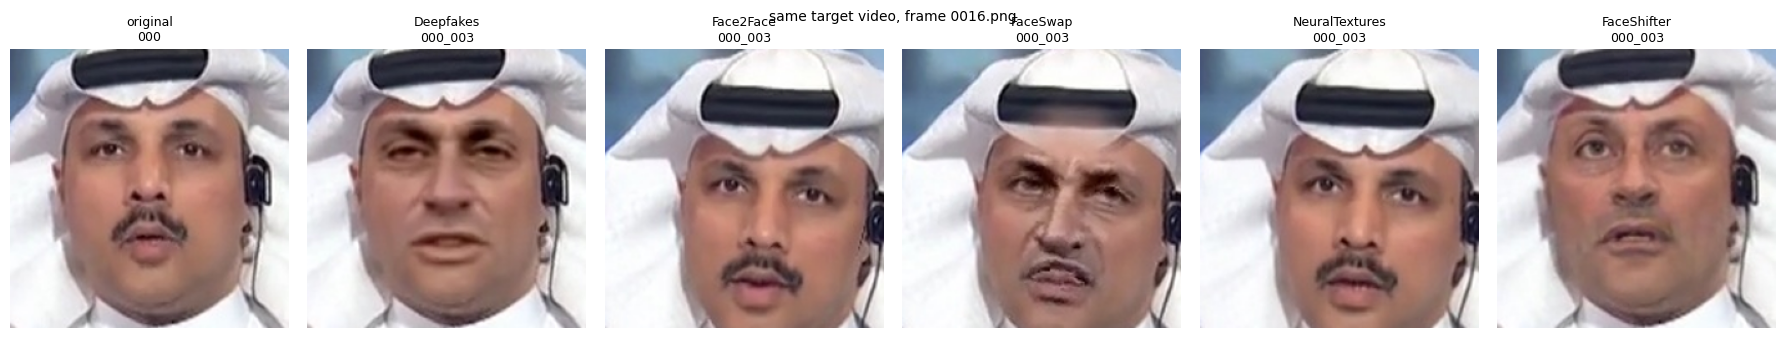

In [12]:
# 3.4 Smoke test: 3 originals and their fakes
smoke = video_ids("original")[:3]
run_originals(smoke)
run_manipulated(manipulated_tasks(set(smoke)))

target = smoke[0]
real_crops = sorted((FACES_ROOT / "original" / target).glob(f"*.{IMAGE_FORMAT}"))
frame = real_crops[len(real_crops) // 2].name
panels = [(f"original\n{target}", FACES_ROOT / "original" / target / frame)]
for m in MANIPULATIONS:
    for fake_dir in sorted((FACES_ROOT / m).glob(f"{target}_*")):
        crops_here = sorted(fake_dir.glob(f"*.{IMAGE_FORMAT}"))
        if (fake_dir / frame).exists():
            panels.append((f"{m}\n{fake_dir.name}", fake_dir / frame))
        elif crops_here:
            panels.append((f"{m}\n{fake_dir.name} (other frame)", crops_here[len(crops_here) // 2]))

fig, axes = plt.subplots(1, len(panels), figsize=(3 * len(panels), 3.4), squeeze=False)
for ax, (title, path) in zip(axes[0], panels):
    ax.imshow(Image.open(path))
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.suptitle(f"same target video, frame {frame}", fontsize=10)
plt.tight_layout()
plt.show()

### 3.5 Full extraction

About 1000 originals (GPU detection) and 5000 fakes (CPU cropping); expect roughly an hour or two with pre-extracted frames. Things to know:

- The kernel keeps working if the browser tab closes; only the live progress bar is lost. After reconnecting, run section 4 to see progress.
- **Resuming later (hours or days):** open the notebook, run 1.1, 1.3, 2.1, 3.1, 3.2, 3.3, then this cell. Skip 1.2 (already installed), 2.2 and 3.4. Finished videos are skipped quickly; interrupted ones only get their missing crops.
- You can stop the cell at any time (Kernel → Interrupt) without damaging anything.
- If your C-DAC session has a time limit, run the two lines separately: originals first, manipulations in a later session.
- Don't run this in two notebooks at once on the same `DATA_ROOT`.

In [13]:
# 3.5 Full extraction (safe to rerun: finished videos are skipped)
run_originals(video_ids("original"))
run_manipulated(manipulated_tasks())

original: 100%|██████████| 1000/1000 [00:01<00:00, 954.84it/s]


{'skipped (done earlier)': 1000}


manipulated: 100%|██████████| 5000/5000 [00:01<00:00, 2559.39it/s]

{'skipped (done earlier)': 5000, 'frames with nearest box': 0}


## 4. Extraction check

Reads only what is on disk, so it can be run any time after 1.1, 1.3 and 2.1, e.g. after reconnecting to see how far extraction got. Expected when finished: about 1000 `done` per category, 0 `partial`, 0 `not started`, and about 32 frames per video.

- `partial` = interrupted part-way; the next run of 3.5 completes it.
- `failed` = no face / unreadable / no frames; skipped on reruns unless `RETRY_FAILED = True`.

In [14]:
# 4. Extraction check
def extraction_summary():
    rows, failed = [], []
    for cat in CATEGORIES:
        ids = video_ids(cat)
        counts, n_frames = Counter(), 0
        for vid in ids:
            d = FACES_ROOT / cat / vid
            if (d / "_done").exists():
                counts["done"] += 1
                n_frames += len(list(d.glob(f"*.{IMAGE_FORMAT}")))
            elif (d / "_failed").exists():
                counts["failed"] += 1
                failed.append({"video_id": f"{cat}/{vid}", "reason": (d / "_failed").read_text()})
            elif d.exists() and any(d.glob(f"*.{IMAGE_FORMAT}")):
                counts["partial"] += 1
            else:
                counts["not started"] += 1
        rows.append({"category": cat, "videos": len(ids),
                     **{k: counts[k] for k in ["done", "partial", "failed", "not started"]},
                     "frames": n_frames, "frames/video": round(n_frames / max(counts["done"], 1), 1)})
    return pd.DataFrame(rows), pd.DataFrame(failed, columns=["video_id", "reason"])


progress, failures = extraction_summary()
display(progress)
print(f"failed videos: {len(failures)}")
if len(failures):
    display(failures.reason.value_counts().to_frame())
    display(failures.head(20))

log = FACES_ROOT / "extraction_log.tsv"
if log.exists():
    events = pd.read_csv(log, sep="\t", names=["time", "video_id", "event"], quoting=3)  # 3 = no quote parsing
    errors = events[events.event.str.startswith("error")]
    nearest = events[events.event.str.contains("nearest original box")]
    print(f"errors logged so far: {len(errors)} (these videos are retried automatically)")
    print(f"fake videos that used a nearest original box: {nearest.video_id.nunique()}")
    if len(errors):
        display(errors.tail(10))

,category,videos,done,partial,failed,not started,frames,frames/video
0,original,1000,1000,0,0,0,32000,32.0
1,Deepfakes,1000,1000,0,0,0,32000,32.0
2,Face2Face,1000,1000,0,0,0,32000,32.0
3,FaceSwap,1000,1000,0,0,0,32000,32.0
4,NeuralTextures,1000,1000,0,0,0,32000,32.0
5,FaceShifter,1000,1000,0,0,0,32000,32.0


failed videos: 0


## 5. Index

One row per face crop, saved to `INDEX_CSV`. All later milestones load data only through this file. Needs 1.1, 1.3 and 2.3.

| column | meaning |
|---|---|
| `split` | train / val / test (official FF++ splits) |
| `label` | 0 = real, 1 = fake |
| `generator` | `original` or the manipulation name (used for per-generator latents and leave-one-generator-out) |
| `video_id` | folder name, e.g. `071` or `071_054` |
| `target_id`, `source_id` | for fakes: target face video and source video; for originals: `target_id = video_id`, `source_id` empty |
| `frame_idx` | frame key (frame number in the video) |
| `path` | crop path relative to `FACES_ROOT` |
| `pair_path` | for fakes: the real crop of the same target and frame (same box), empty if missing |

In [16]:
# 5. Build the index
def split_members(pairs):
    originals = {v for pair in pairs for v in pair}
    fakes = {f"{a}_{b}" for a, b in pairs} | {f"{b}_{a}" for a, b in pairs}
    return originals, fakes


rows, missing = [], []
for split in EXPECTED_PAIRS:
    originals, fakes = split_members(json.loads((SPLITS_DIR / f"{split}.json").read_text()))
    for generator in CATEGORIES:
        members = originals if generator == "original" else fakes
        for vid in sorted(members):
            folder = FACES_ROOT / generator / vid
            if not (folder / "_done").exists():
                missing.append((split, generator, vid))
                continue
            target, _, source = vid.partition("_")
            for crop in sorted(folder.glob(f"*.{IMAGE_FORMAT}")):
                pair = FACES_ROOT / "original" / target / crop.name
                rows.append({
                    "split": split,
                    "label": int(generator != "original"),
                    "generator": generator,
                    "video_id": vid,
                    "target_id": target,
                    "source_id": source,
                    "frame_idx": int(crop.stem),
                    "path": crop.relative_to(FACES_ROOT).as_posix(),
                    "pair_path": pair.relative_to(FACES_ROOT).as_posix()
                                 if generator != "original" and pair.exists() else "",
                })

index = pd.DataFrame(rows)
index.to_csv(INDEX_CSV, index=False)
print(f"saved {len(index):,} rows -> {INDEX_CSV}")

cols = list(EXPECTED_PAIRS)
print("\nvideos per generator x split")
display(index.groupby(["generator", "split"]).video_id.nunique().unstack().reindex(index=CATEGORIES, columns=cols))
print("frames per generator x split")
display(index.groupby(["generator", "split"]).size().unstack().reindex(index=CATEGORIES, columns=cols))

fake = index[index.label == 1]
print(f"fake crops with a paired real crop: {100 * (fake.pair_path != '').mean():.2f}%")
print(f"videos in the splits without crops: {len(missing)}")
if missing:
    display(pd.DataFrame(missing, columns=["split", "generator", "video_id"]).head(20))

saved 192,000 rows -> /nlsasfs/home/isea/isea64/GBLA-Deepfake Detection/index/ffpp_c23.csv

videos per generator x split


split,train,val,test
generator,,,
original,720,140,140
Deepfakes,720,140,140
Face2Face,720,140,140
FaceSwap,720,140,140
NeuralTextures,720,140,140
FaceShifter,720,140,140


frames per generator x split


split,train,val,test
generator,,,
original,23040,4480,4480
Deepfakes,23040,4480,4480
Face2Face,23040,4480,4480
FaceSwap,23040,4480,4480
NeuralTextures,23040,4480,4480
FaceShifter,23040,4480,4480


fake crops with a paired real crop: 100.00%
videos in the splits without crops: 0


In [17]:
print(len(rows))
print(len(missing))

192000
0


## 6. Parameter report

Independent of the data, so it can be run right after section 1.

**6.1** counts the CLIP visual towers (frozen backbone size is reported, not hidden). The adapted set is all LayerNorm parameters plus a linear real/fake head on the `width`-dimensional CLS feature (the final projection is not used). Expected for ViT-L/14: 50 LayerNorms, 102,400 LN parameters, head 2,050, total adapted P = 104,450.

**6.2** shows the GBLA budget for G = 4 training generators. The adapted parameters are generated as θ = θ₀ + α·W·z, where W (P × d) is random and regenerated from a seed, so it is never stored or trained.

- trainable stored: shared z (d) + G private z_g (G·d) + α (1)
- trainable free: one fewer private vector, because the private latents are centred to sum to zero
- deployed: z (d) + α (1) + the seed; the private latents are discarded after training

In [18]:
# 6.1 CLIP visual tower counts
import open_clip
import torch.nn as nn

towers = {}
for arch in ["ViT-B-16", "ViT-L-14"]:
    visual = open_clip.create_model(arch, pretrained="openai").visual.requires_grad_(False)
    width = visual.transformer.width
    lns = [m for m in visual.modules() if isinstance(m, nn.LayerNorm)]
    ln_params = sum(p.numel() for m in lns for p in m.parameters())
    head = 2 * width + 2
    towers[arch] = {
        "total (frozen)": sum(p.numel() for p in visual.parameters()),
        "of which final projection (unused)": visual.proj.numel() if visual.proj is not None else 0,
        "trainable now": sum(p.numel() for p in visual.parameters() if p.requires_grad),
        "width": width,
        "LayerNorm modules": len(lns),
        "LayerNorm params": ln_params,
        "head params (2*width+2)": head,
        "adapted P = LN + head": ln_params + head,
    }
    del visual

param_table = pd.DataFrame(towers)
param_table.style.format("{:,}")

/nlsasfs/home/isea/isea64/venv_jupyter/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


,ViT-B-16,ViT-L-14
total (frozen),"86,192,640","303,966,208"
of which final projection (unused),"393,216","786,432"
trainable now,0,0
width,768,"1,024"
LayerNorm modules,26,50
LayerNorm params,"39,936","102,400"
head params (2*width+2),"1,538","2,050"
adapted P = LN + head,"41,474","104,450"


In [19]:
# 6.2 GBLA parameter budget
LATENT_DIMS = [16, 64, 256, 1024]
G_TRAIN = 4

budget = []
for arch, t in towers.items():
    P = t["adapted P = LN + head"]
    for d in LATENT_DIMS:
        budget.append({
            "arch": arch,
            "d": d,
            "P": P,
            "W entries (seed only, 0 stored)": P * d,
            "trainable stored": d + G_TRAIN * d + 1,
            "trainable free": d + (G_TRAIN - 1) * d + 1,
            "deployed": d + 1,
            "deployed % of tower": 100 * (d + 1) / t["total (frozen)"],
            "plain LN-tuning % of tower": 100 * P / t["total (frozen)"],
        })

budget = pd.DataFrame(budget)
budget.style.format({**{c: "{:,}" for c in budget.columns[2:7]},
                     "deployed % of tower": "{:.6f}", "plain LN-tuning % of tower": "{:.4f}"})

,arch,d,P,"W entries (seed only, 0 stored)",trainable stored,trainable free,deployed,deployed % of tower,plain LN-tuning % of tower
0,ViT-B-16,16,"41,474","663,584",81,65,17,0.000020,0.0481
1,ViT-B-16,64,"41,474","2,654,336",321,257,65,0.000075,0.0481
2,ViT-B-16,256,"41,474","10,617,344","1,281","1,025",257,0.000298,0.0481
3,ViT-B-16,1024,"41,474","42,469,376","5,121","4,097","1,025",0.001189,0.0481
4,ViT-L-14,16,"104,450","1,671,200",81,65,17,0.000006,0.0344
5,ViT-L-14,64,"104,450","6,684,800",321,257,65,0.000021,0.0344
6,ViT-L-14,256,"104,450","26,739,200","1,281","1,025",257,0.000085,0.0344
7,ViT-L-14,1024,"104,450","106,956,800","5,121","4,097","1,025",0.000337,0.0344


## 7. Send results back

1. Save this notebook (Ctrl+S) with its outputs.
2. In a terminal cell or C-DAC terminal, from the repository folder:

```bash
git pull
git add M0.ipynb
git commit -m "M0 run outputs"
git push
```

When git asks for a password, paste your GitHub token. Do not put the token in this notebook or any file, and do not send it to me.

Only `M0.ipynb` is committed: the input data, crops and index CSV stay on C-DAC. Then tell me it is pushed, and I will pull and read the outputs.

**What I need from the outputs:** the environment table (1.3), the data tables (2.1, 2.2) and the example frames, the smoke-test figure (3.4), the extraction check (4), the index tables (5), and both parameter tables (6).

**Suggested first push:** run 1.1 → 2.3 and section 6 first, push, and let me confirm the frame layout from 2.2 before you start 3.5.